In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Load & prepare MNIST (same subset as Class 4)
print('Loading MNIST...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data.astype(np.float32) / 255.0
y_all = mnist.target.astype(int)

X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all, train_size=10_000, random_state=42, stratify=y_all
)

# Train / Val / Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_sub, y_sub, test_size=0.15, random_state=42, stratify=y_sub
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp
)

def one_hot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_train = one_hot(y_train)
Y_val   = one_hot(y_val)
Y_test  = one_hot(y_test)

print(f'Train {X_train.shape[0]} | Val {X_val.shape[0]} | Test {X_test.shape[0]}')

Loading MNIST...
Train 7000 | Val 1500 | Test 1500


In [50]:
# Helper functions (same as Class 4)

def relu(z):           return np.maximum(0, z)
def relu_grad(z):      return (z > 0).astype(float)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(probs, Y):
    return -np.sum(Y * np.log(probs + 1e-9)) / Y.shape[0]

def init_he(shape):
    return np.random.randn(*shape) * np.sqrt(2.0 / shape[0])

def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)
    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [51]:
class NeuralNet:

  def __init__(self, input_size=784, h1=128, h2=64, output_size=10, init_fn=init_he, l2_lambda=0.0, l1_lambda=0.0, dropout=0.0):

    self.l2_lambda=l2_lambda
    self.l1_lambda=l1_lambda
    self.dropout=dropout

    self.W1 = init_fn((input_size, h1))
    self.b1 = np.zeros((1, h1))

    self.W2 = init_fn((h1, h2))
    self.b2 = np.zeros((1, h2))

    self.W3 = init_fn((h2, output_size))
    self.b3 = np.zeros((1, output_size))

  def forward(self, X, training=True):
    # trainig=True -> dropout active (during training)
    # training=False -> dropout off (during val/test time)

    self.X_input = X

    # Layer 1
    self.Z1 = X @ self.W1 + self.b1
    self.A1 = relu(self.Z1)

    # dropout layer 1
    # randomly turns off neurons - zero out neurons.
    # only drop neurons during training, at test time you want all neurons working their best
    if training and self.dropout > 0:
      self.mask1 = (np.random.rand(*self.A1.shape) > self.dropout) # generates random numbers between 0 and 1. If the random number is greater than the dropout rate (e.g. 0.4),
      #the neuron survives (True = 1). Otherwise it's dropped (False = 0). This creates a mask the same shape as your activations.
      self.A1 = self.A1 * self.mask1 / (1.0 - self.dropout) # multiply by the mask → dropped neurons become 0
      # scale up the surviving neurons to compensate. If 40% of neurons are turned off, the other 60% need to be louder so the total signal stays the similar magnitude
    else:
      self.mask1 = None

    # Layer 2
    self.Z2 = self.A1 @ self.W2 + self.b2
    self.A2 = relu(self.Z2)

    # dropout layer 2
    if training and self.dropout > 0:
      self.mask2 = (np.random.rand(*self.A2.shape) > self.dropout)
      self.A2 = self.A2 * self.mask2 / (1.0 - self.dropout)
    else:
      self.mask2 = None

    # output layer
    self.Z3 = self.A2 @ self.W3 + self.b3
    self.probs = softmax(self.Z3)

    return self.probs

  def backward(self, X, Y):
    n = X.shape[0]

    # output layer
    dZ3 = (self.probs - Y) / n
    self.dW3 = self.A2.T @ dZ3
    self.db3 = dZ3.sum(axis=0, keepdims=True)

    # layer 2 - propagating through dropout mask if active
    dA2 = dZ3 @ self.W3.T
    if self.mask2 is not None: # a neuron that was zeroed out going forward must also be zeroed out going backward
      dA2 = dA2 * self.mask2 / (1.0 - self.dropout)
    dZ2 = dA2 * relu_grad(self.Z2)
    self.dW2 = self.A1.T @ dZ2
    self.db2 = dZ2.sum(axis=0, keepdims=True)

    # layer 1
    dA1 = dZ2 @ self.W2.T
    if self.mask1 is not None:
      dA1 = dA1 * self.mask1 / (1.0 - self.dropout)
    dZ1 = dA1 * relu_grad(self.Z1)
    self.dW1 = X.T @ dZ1
    self.db1 = dZ1.sum(axis=0, keepdims=True)

    # regularization gradients
    # L2: penalize large weights
    # L1: penalize weight magnitude
    for dW, W in [(self.dW1, self.W1), (self.dW2, self.W2), (self.dW3, self.W3)]:
      dW += self.l2_lambda * W # L2 gradient
      dW += self.l1_lambda * np.sign(W) # L1 gradient

  def update(self, lr):
    self.W1 -= lr * self.dW1
    self.b1 -= lr * self.db1
    self.W2 -= lr * self.dW2
    self.b2 -= lr * self.db2
    self.W3 -= lr * self.dW3
    self.b3 -= lr * self.db3

  def predict(self, X):
    return np.argmax(self.forward(X, training=False), axis=1)

  def accuracy(self, X, y):
    return 100.0 * np.mean(self.predict(X) == y)

In [52]:
def train(model, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30, lr=0.0001, batch_size=128, verbose=True):
  n = X_train.shape[0] # n of samples, n of features

  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

  for epoch in range(1, epochs + 1):
    idx = np.random.permutation(n)
    Xs, Ys = X_train[idx], Y_train[idx]
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, n, batch_size):
      Xb = Xs[start:start + batch_size]
      Yb = Ys[start: start + batch_size]
      probs = model.forward(Xb, training=True)
      epoch_loss += cross_entropy_loss(probs, Yb)
      model.backward(Xb, Yb)
      model.update(lr)
      n_batches += 1

    t_loss = epoch_loss / n_batches
    v_loss = cross_entropy_loss(model.forward(X_val, training=False), Y_val)
    t_acc = model.accuracy(X_train, y_train)
    v_acc = model.accuracy(X_val, y_val)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if verbose and (epoch % 10 == 0 or epoch == 1):
      print(f'Epoch {epoch:3d} | ' f'Train loss {t_loss:.4f} acc {t_acc:.1f}% | ' f'Val loss {v_loss:.4f} acc {v_acc:.1f}%')

  return history

# Underfit

Epoch   1 | Train loss 2.4528 acc 13.1% | Val loss 2.4468 acc 12.3%
Epoch  10 | Train loss 2.3429 acc 15.9% | Val loss 2.3453 acc 15.2%
Epoch  20 | Train loss 2.2902 acc 18.0% | Val loss 2.2952 acc 17.1%
Epoch  30 | Train loss 2.2597 acc 19.1% | Val loss 2.2650 acc 18.1%


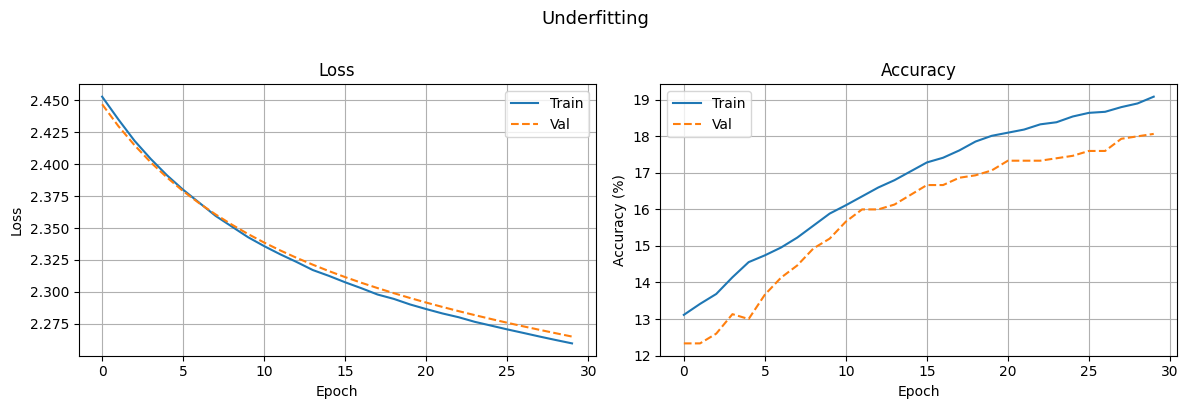

In [53]:
net_underfit = NeuralNet(h1=16, h2=8)
hist_underfit = train(net_underfit, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)

plot_history(hist_underfit, 'Underfitting')

Fixed underfitting: larger network
Epoch   1 | Train loss 2.3130 acc 13.9% | Val loss 2.2838 acc 13.1%
Epoch  10 | Train loss 1.8652 acc 53.8% | Val loss 1.8455 acc 54.5%
Epoch  20 | Train loss 1.4197 acc 70.9% | Val loss 1.4055 acc 71.7%
Epoch  30 | Train loss 1.0910 acc 76.7% | Val loss 1.0817 acc 77.7%


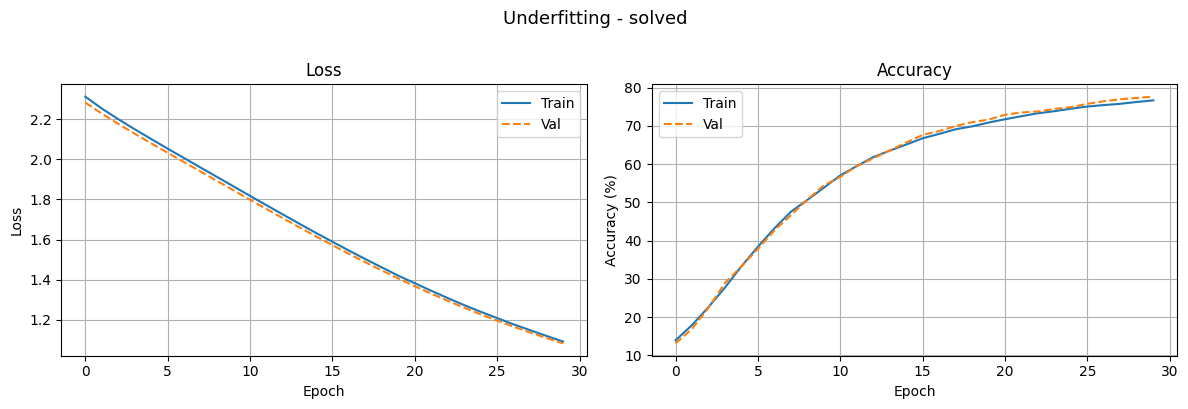

In [54]:
print('Fixed underfitting: larger network')
net_baseline = NeuralNet(h1=128, h2=64)
hist_baseline = train(net_baseline, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30, lr=0.001)

plot_history(hist_baseline, 'Underfitting - solved')

# Overfitting

Epoch   1 | Train loss 2.1530 acc 63.8% | Val loss 1.8556 acc 57.6%
Epoch  10 | Train loss 0.4403 acc 85.5% | Val loss 0.6542 acc 78.5%
Epoch  20 | Train loss 0.1697 acc 97.8% | Val loss 0.4527 acc 85.7%
Epoch  30 | Train loss 0.0971 acc 99.7% | Val loss 0.4278 acc 87.0%


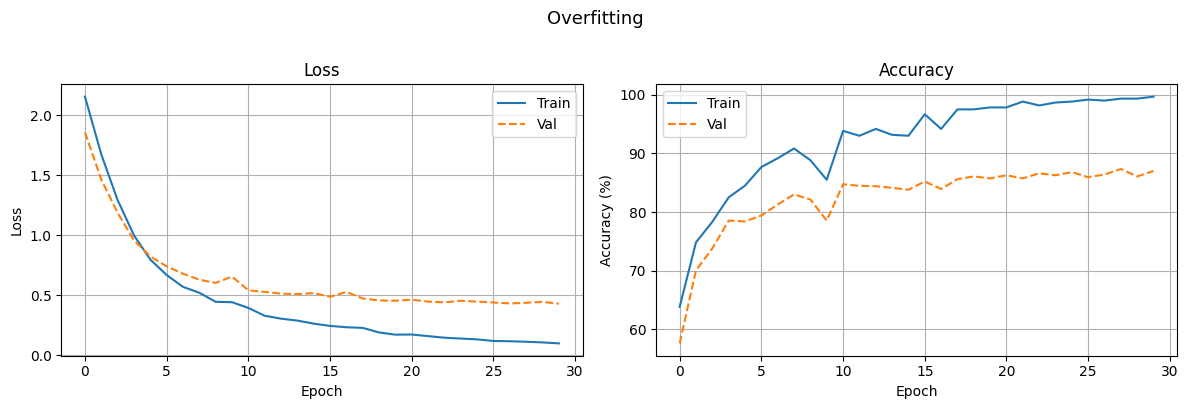

In [60]:
N_SMALL = 600
X_small = X_train[:N_SMALL]
Y_small = Y_train[:N_SMALL]
y_small = y_train[:N_SMALL]

net_overfit = NeuralNet(h1=256, h2=128)
hist_overfit = train(net_overfit, X_small, Y_small, y_small, X_val, Y_val, y_val, epochs=30, lr=0.1)

plot_history(hist_overfit, 'Overfitting')

Epoch   1 | Train loss 2.3591 acc 11.7% | Val loss 2.3214 acc 10.1%
Epoch  10 | Train loss 1.9518 acc 51.8% | Val loss 1.9620 acc 44.7%
Epoch  20 | Train loss 1.5527 acc 69.0% | Val loss 1.5967 acc 63.5%
Epoch  30 | Train loss 1.2162 acc 78.0% | Val loss 1.2830 acc 72.3%
Epoch  40 | Train loss 0.9576 acc 82.2% | Val loss 1.0515 acc 77.1%
Epoch  50 | Train loss 0.7759 acc 83.8% | Val loss 0.8927 acc 80.2%
Epoch  60 | Train loss 0.6538 acc 86.7% | Val loss 0.7880 acc 81.1%


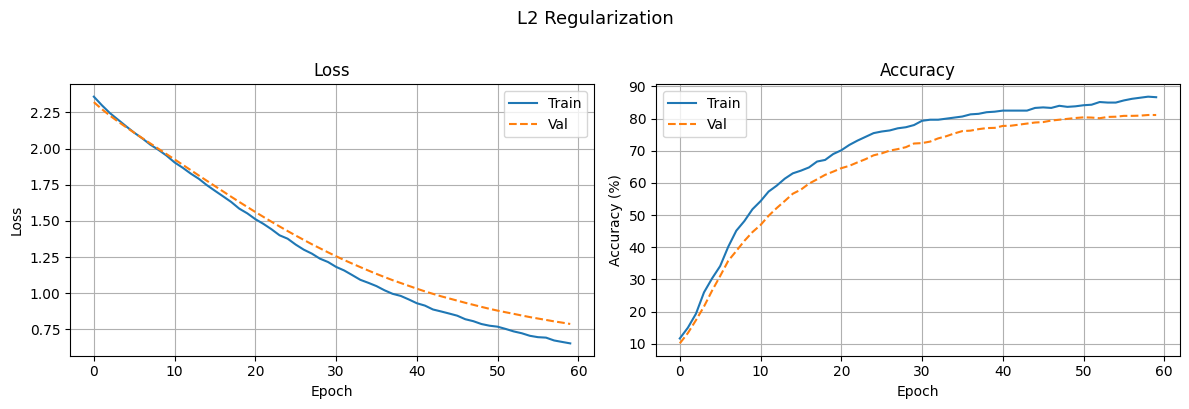

In [61]:
# L2

net_l2 = NeuralNet(h1=256, h2=128, l2_lambda=0.01)
hist_l2 = train(net_l2, X_small, Y_small, y_small, X_val, Y_val, y_val, epochs=60, lr=0.01)

plot_history(hist_l2, 'L2 Regularization')

Epoch   1 | Train loss 2.3553 acc 11.8% | Val loss 2.3242 acc 10.7%
Epoch  10 | Train loss 1.9670 acc 46.7% | Val loss 1.9850 acc 44.7%
Epoch  20 | Train loss 1.6957 acc 66.2% | Val loss 1.7357 acc 63.3%
Epoch  30 | Train loss 1.4983 acc 74.5% | Val loss 1.5497 acc 70.6%
Epoch  40 | Train loss 1.3587 acc 79.0% | Val loss 1.4212 acc 74.3%
Epoch  50 | Train loss 1.2700 acc 81.0% | Val loss 1.3390 acc 75.8%
Epoch  60 | Train loss 1.2252 acc 81.8% | Val loss 1.2905 acc 77.6%


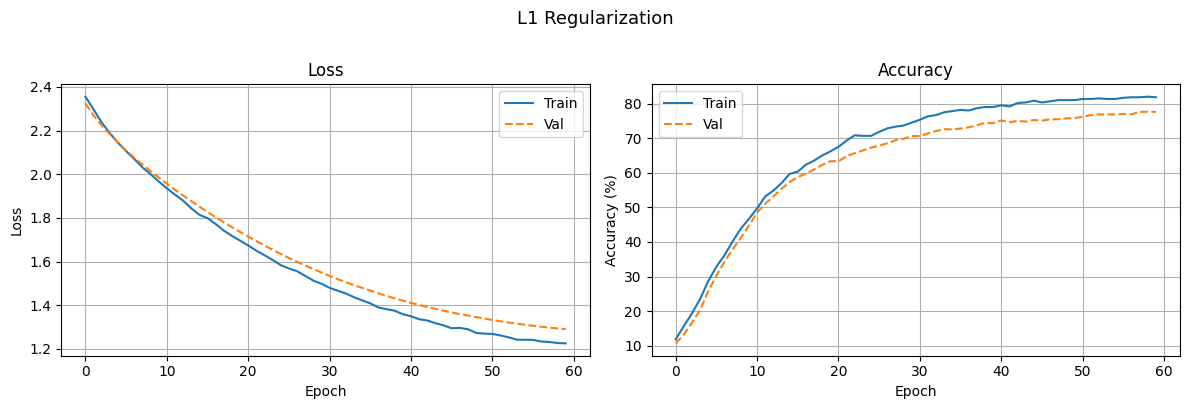

In [62]:
# L1

net_l1 = NeuralNet(h1=256, h2=128, l1_lambda=0.01)
hist_l1 = train(net_l1, X_small, Y_small, y_small, X_val, Y_val, y_val, epochs=60, lr=0.01)

plot_history(hist_l1, 'L1 Regularization')

Epoch   1 | Train loss 2.4193 acc 12.8% | Val loss 2.2898 acc 12.9%
Epoch  10 | Train loss 2.0486 acc 52.5% | Val loss 1.9477 acc 47.5%
Epoch  20 | Train loss 1.7426 acc 72.8% | Val loss 1.6332 acc 69.1%
Epoch  30 | Train loss 1.4139 acc 77.0% | Val loss 1.3344 acc 75.0%
Epoch  40 | Train loss 1.2312 acc 80.2% | Val loss 1.0923 acc 77.9%
Epoch  50 | Train loss 1.0391 acc 84.5% | Val loss 0.9236 acc 79.7%
Epoch  60 | Train loss 0.9534 acc 88.2% | Val loss 0.8094 acc 81.1%


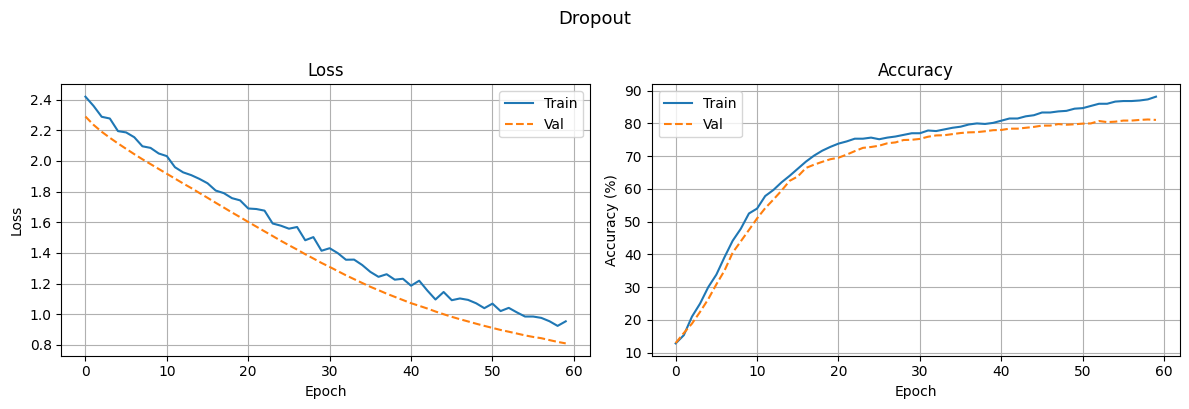

In [63]:
# Dropout
N_SMALL = 600
X_small = X_train[:N_SMALL]
Y_small = Y_train[:N_SMALL]
y_small = y_train[:N_SMALL]

net_drop = NeuralNet(h1=256, h2=128, dropout=0.3)
hist_drop = train(net_drop, X_small, Y_small, y_small, X_val, Y_val, y_val, epochs=60, lr=0.01)

plot_history(hist_drop, 'Dropout')